In [ ]:
!pip install ultralytics --quiet

In [ ]:
!pip install grad-cam --quiet

In [ ]:
import kagglehub

path = kagglehub.dataset_download("saathvik16/bdd100k-object-dection-with-yolo-format-labels")

print("Path to dataset files:", path)

In [ ]:
data_yaml_content = """
train: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/train/images
val: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images
test: /kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/test/images

nc: 10

names:
  0: bike
  1: bus
  2: car
  3: motor
  4: person
  5: rider
  6: traffic light
  7: traffic sign
  8: train
  9: truck
"""
dataset_yaml_path = '/kaggle/working/data.yaml'
with open(dataset_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"data.yaml created at: {dataset_yaml_path}")

In [36]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import os
import random
import yaml
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from ultralytics import YOLO
from pytorch_grad_cam import EigenCAM, GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

# --- Directories ---
os.makedirs('/kaggle/working/report_images', exist_ok=True)
os.makedirs('/kaggle/working/ppt_images', exist_ok=True)

# --- Configuration ---
num_images = 50
val_imgs_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/images"
val_labels_dir = "/kaggle/input/bdd100k-object-dection-with-yolo-format-labels/100k-dataset/val/labels"
dataset_yaml_path = '/kaggle/working/data.yaml'

early_exit_weights_path = '/kaggle/input/yolov8m-weights-trained-early-and-final/yolov8m_early_exit_dual_scale.pt'
final_exit_weights_path = '/kaggle/input/yolov8m-weights-trained-early-and-final/yolov8m_final_exit.pt'
upfront_regressor_path = '/kaggle/input/yolov8m-weights-trained-early-and-final/f1_predictor_mobilenet_v3_small.pth'

with open(dataset_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']

transform_reg = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [37]:
def yolo_to_xyxy(bbox_norm, img_shape):
    h, w = img_shape[:2]
    x_c, y_c, bw, bh = bbox_norm
    x1, y1 = int((x_c - bw / 2) * w), int((y_c - bh / 2) * h)
    x2, y2 = int((x_c + bw / 2) * w), int((y_c + bh / 2) * h)
    return [max(0, x1), max(0, y1), min(w, x2), min(h, y2)]

def bbox_iou(box1, box2):
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0

def mean_iou(gt_boxes, pred_boxes):
    if not gt_boxes or not pred_boxes: return 0.0
    ious = [max([bbox_iou(gt, pred) for pred in pred_boxes]) for gt in gt_boxes]
    return np.mean(ious)

def get_gt_viz(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                class_id, x_c, y_c, bw, bh = map(float, line.strip().split())
                x1, y1, x2, y2 = yolo_to_xyxy([x_c, y_c, bw, bh], (h, w))
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, class_names[int(class_id)], (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
    return img

In [38]:
class YOLOv8Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        result = self.model(x)
        preds = result[0] if isinstance(result, (list, tuple)) else result
        return preds[:, 4:, :].sum().unsqueeze(0)

class RawOutputTarget:
    def __init__(self): pass
    def __call__(self, model_output): return model_output.sum()

def get_cam_viz(model, layer_idx, img_rgb, method="eigen", is_yolo=True):
    h_orig, w_orig = img_rgb.shape[:2]
    img_input = cv2.resize(img_rgb, (640, 640)) if is_yolo else cv2.resize(img_rgb, (224, 224))
    img_float = np.float32(img_input) / 255.0
    input_tensor = torch.from_numpy(img_float).permute(2, 0, 1).unsqueeze(0).to('cpu')
    input_tensor.requires_grad = True

    wrapped_model = YOLOv8Wrapper(model) if is_yolo else model
    target_layers = [model.model[layer_idx]] if is_yolo else [model.features[-1]]
    targets = [RawOutputTarget()]
    
    if method == "eigen":
        cam_obj = EigenCAM(model=wrapped_model, target_layers=target_layers)
        grayscale = cam_obj(input_tensor=input_tensor, targets=targets)[0, :]
    else:
        cam_obj = GradCAM(model=wrapped_model, target_layers=target_layers)
        grayscale = cam_obj(input_tensor=input_tensor, targets=targets)[0, :]
    
    grayscale_rescaled = cv2.resize(grayscale, (w_orig, h_orig), interpolation=cv2.INTER_CUBIC)
    return show_cam_on_image(np.float32(img_rgb) / 255.0, grayscale_rescaled, use_rgb=True)

def run_lime_high_res(model, img_rgb):
    h_orig, w_orig = img_rgb.shape[:2]
    explainer = lime_image.LimeImageExplainer()
    img_224 = cv2.resize(img_rgb, (224, 224))
    def batch_predict(images):
        model.eval()
        batch = torch.stack([transform_reg(Image.fromarray((i*255).astype('uint8'))) for i in images])
        return model(batch).detach().numpy()
    explanation = explainer.explain_instance(img_224.astype('double')/255.0, batch_predict, top_labels=1, num_samples=250)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    mask_high = cv2.resize(mask.astype(np.uint8), (w_orig, h_orig), interpolation=cv2.INTER_NEAREST)
    return mark_boundaries(img_rgb / 255.0, mask_high)

  0%|          | 0/250 [00:00<?, ?it/s]

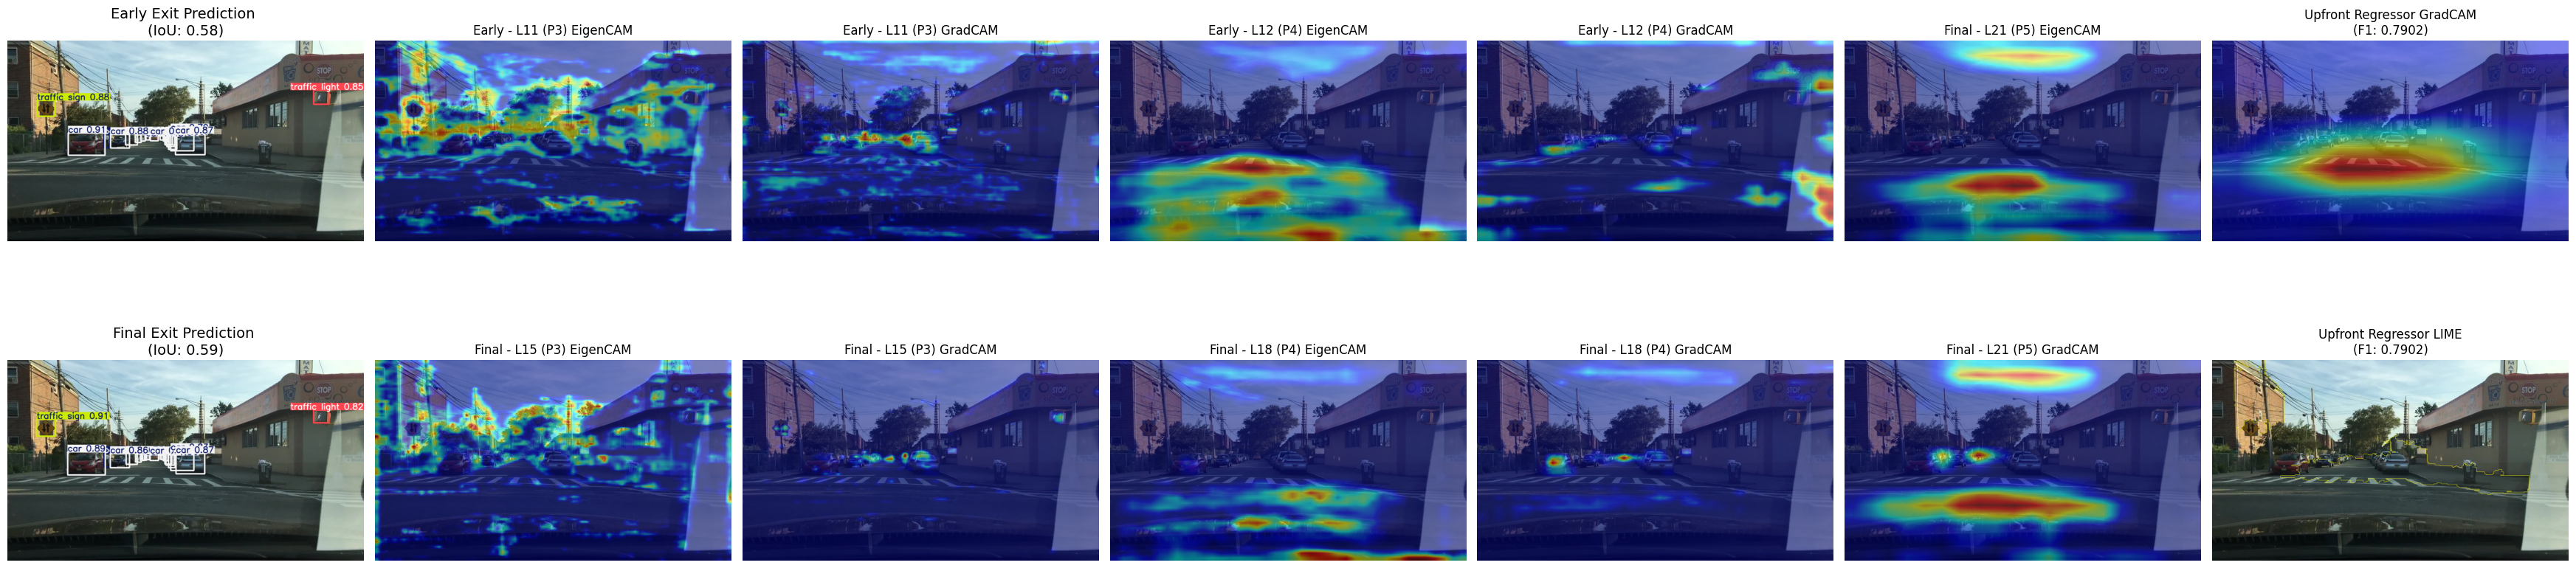

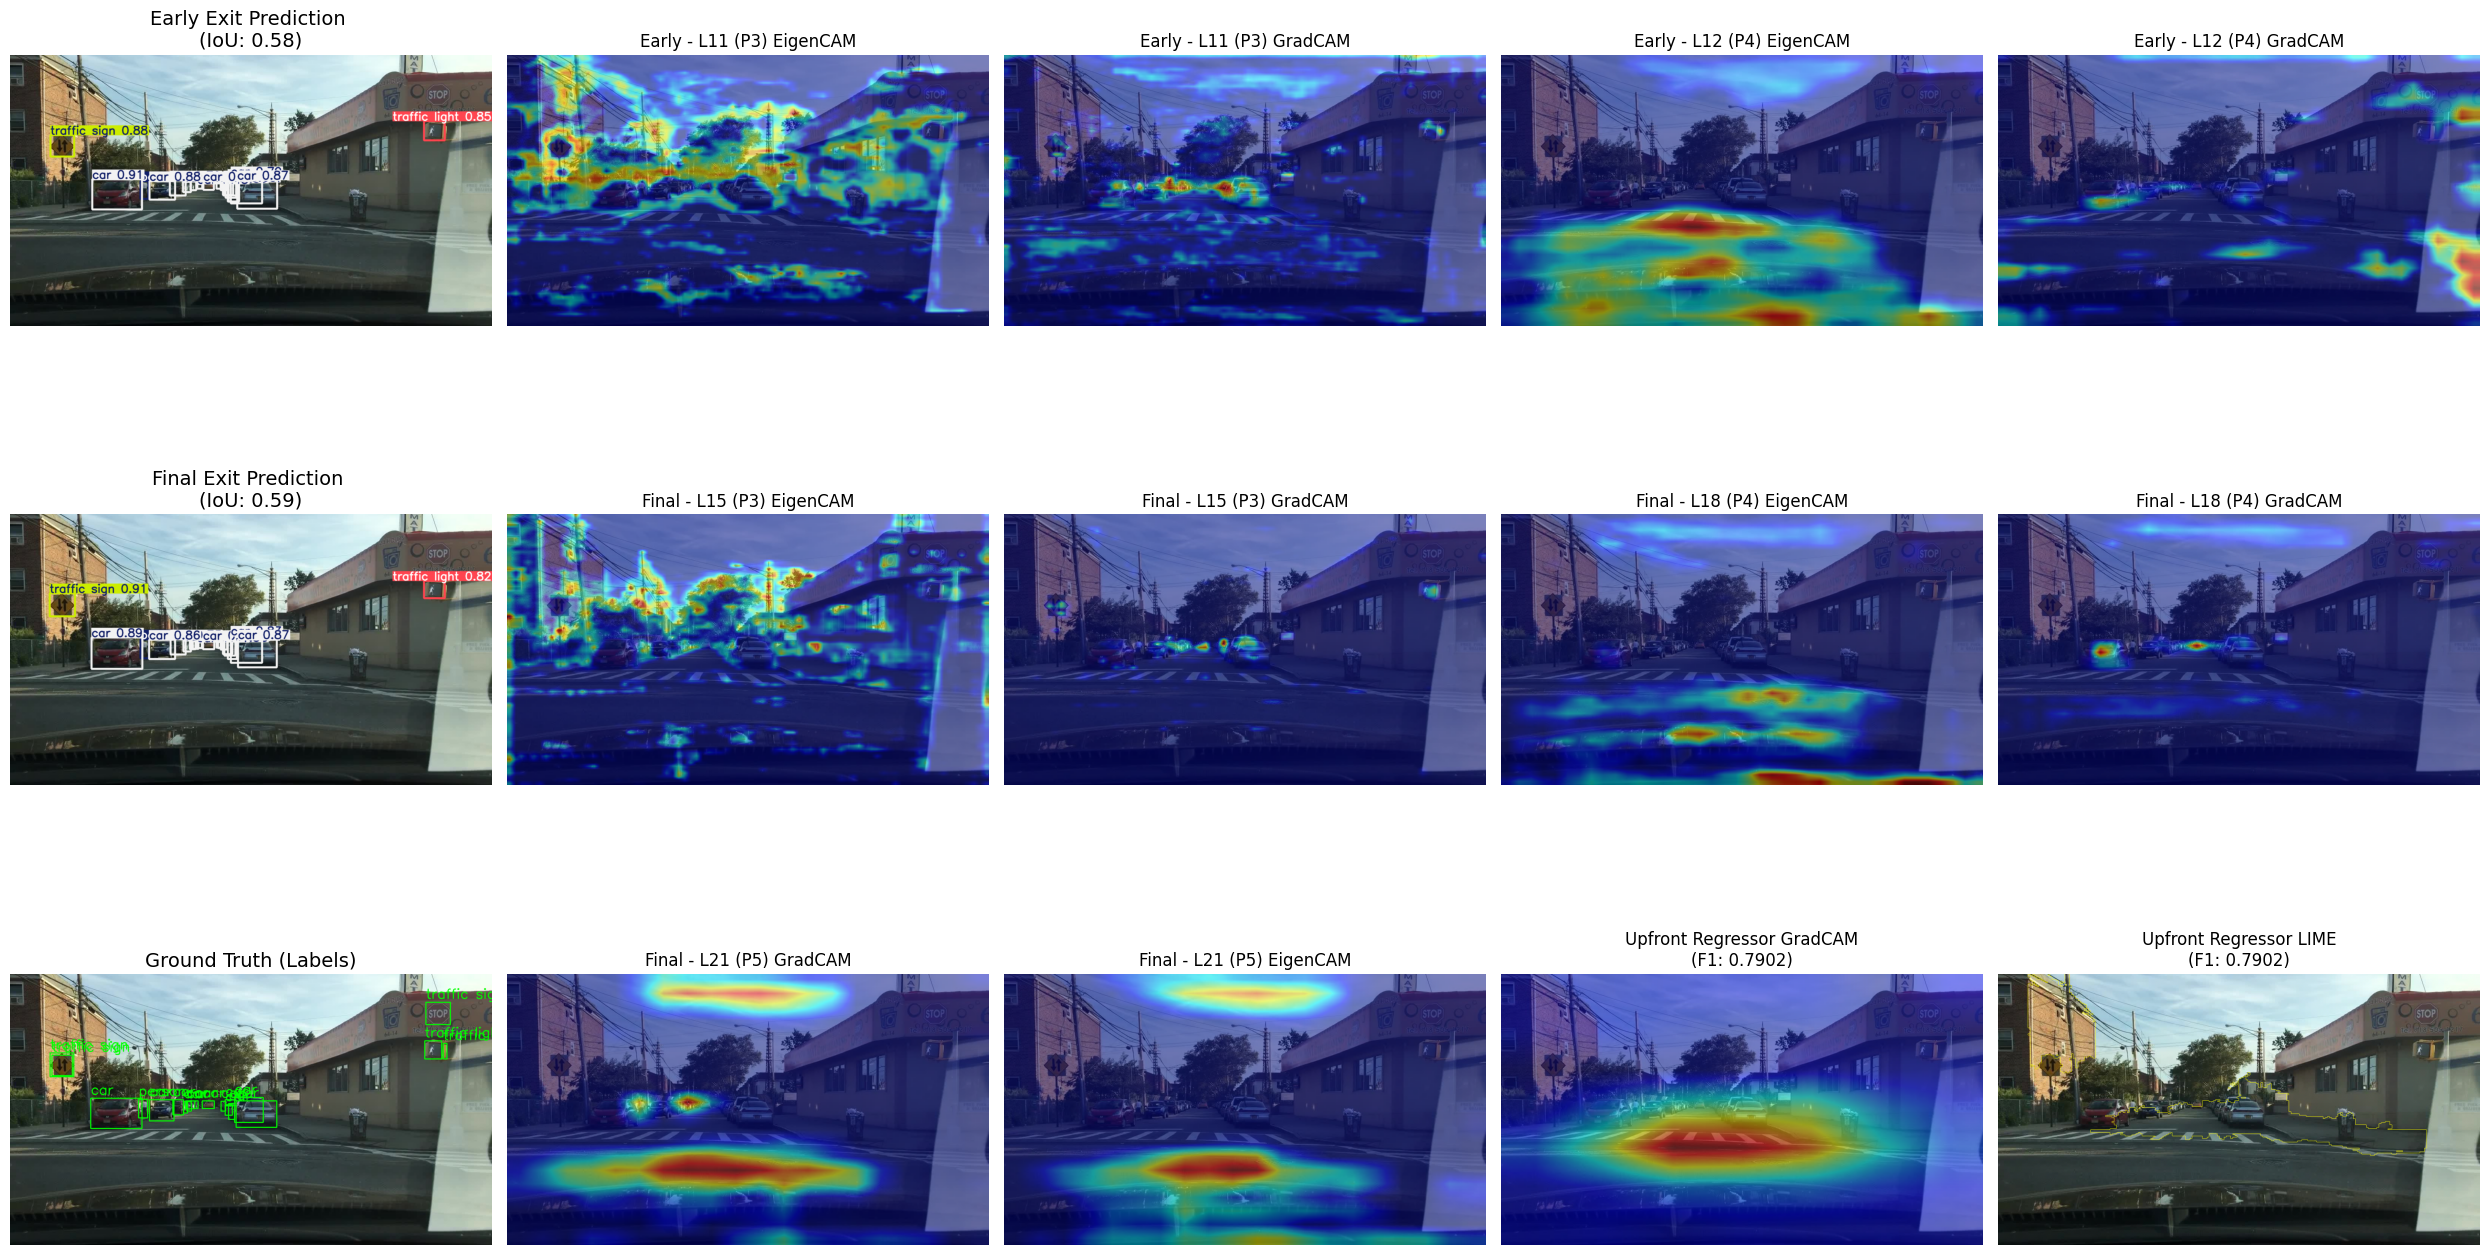

In [39]:
# 1. Load Models
model_early_yolo = YOLO(early_exit_weights_path)
model_final_yolo = YOLO(final_exit_weights_path)
model_e = model_early_yolo.model.to('cpu').eval()
model_f = model_final_yolo.model.to('cpu').eval()

def load_f1_predictor(path):
    model = models.mobilenet_v3_small(weights=None)
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, 1)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    return model
upfront_model = load_f1_predictor(upfront_regressor_path)

# 2. Main Loop
all_imgs = [f for f in os.listdir(val_imgs_dir) if f.lower().endswith(('.jpg', '.png'))]
selected_imgs = random.sample(all_imgs, min(num_images, len(all_imgs)))

for img_name in selected_imgs:
    img_path = os.path.join(val_imgs_dir, img_name)
    lbl_path = os.path.join(val_labels_dir, os.path.splitext(img_name)[0] + ".txt")
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h_orig, w_orig = img_rgb.shape[:2]

    # Predictions & Data
    res_e = model_early_yolo(img_path, verbose=False)[0]
    res_f = model_final_yolo(img_path, verbose=False)[0]
    pred_e_plot = cv2.resize(cv2.cvtColor(res_e.plot(), cv2.COLOR_BGR2RGB), (w_orig, h_orig))
    pred_f_plot = cv2.resize(cv2.cvtColor(res_f.plot(), cv2.COLOR_BGR2RGB), (w_orig, h_orig))
    
    gt_boxes = [yolo_to_xyxy(list(map(float, line.split()))[1:], (h_orig, w_orig)) for line in open(lbl_path)] if os.path.exists(lbl_path) else []
    iou_e = mean_iou(gt_boxes, res_e.boxes.xyxy.cpu().numpy().tolist() if len(res_e.boxes) > 0 else [])
    iou_f = mean_iou(gt_boxes, res_f.boxes.xyxy.cpu().numpy().tolist() if len(res_f.boxes) > 0 else [])
    pred_f1 = upfront_model(transform_reg(Image.fromarray(img_rgb)).unsqueeze(0)).item()

    # Pre-generate common visuals
    e11ec, e11gc = get_cam_viz(model_e, 11, img_rgb, "eigen"), get_cam_viz(model_e, 11, img_rgb, "grad")
    e12ec, e12gc = get_cam_viz(model_e, 12, img_rgb, "eigen"), get_cam_viz(model_e, 12, img_rgb, "grad")
    f15ec, f15gc = get_cam_viz(model_f, 15, img_rgb, "eigen"), get_cam_viz(model_f, 15, img_rgb, "grad")
    f18ec, f18gc = get_cam_viz(model_f, 18, img_rgb, "eigen"), get_cam_viz(model_f, 18, img_rgb, "grad")
    f21ec, f21gc = get_cam_viz(model_f, 21, img_rgb, "eigen"), get_cam_viz(model_f, 21, img_rgb, "grad")
    up_gc = get_cam_viz(upfront_model, -1, img_rgb, "grad", is_yolo=False)
    up_lime = run_lime_high_res(upfront_model, img_rgb)
    gt_plot = get_gt_viz(img_path, lbl_path)

    # --- REPORT IMAGE (2x7) ---
    fig_rep, axes_rep = plt.subplots(2, 7, figsize=(35, 10))
    # Row 1
    axes_rep[0, 0].imshow(pred_e_plot); axes_rep[0, 0].set_title(f"Early Exit Prediction \n(IoU: {iou_e:.2f})", fontsize=14)
    axes_rep[0, 1].imshow(e11ec); axes_rep[0, 1].set_title("Early - L11 (P3) EigenCAM", fontsize=12)
    axes_rep[0, 2].imshow(e11gc); axes_rep[0, 2].set_title("Early - L11 (P3) GradCAM", fontsize=12)
    axes_rep[0, 3].imshow(e12ec); axes_rep[0, 3].set_title("Early - L12 (P4) EigenCAM", fontsize=12)
    axes_rep[0, 4].imshow(e12gc); axes_rep[0, 4].set_title("Early - L12 (P4) GradCAM", fontsize=12)
    axes_rep[0, 5].imshow(f21ec); axes_rep[0, 5].set_title("Final - L21 (P5) EigenCAM", fontsize=12)
    axes_rep[0, 6].imshow(up_gc); axes_rep[0, 6].set_title(f"Upfront Regressor GradCAM\n(F1: {pred_f1:.4f})", fontsize=12)
    # Row 2
    axes_rep[1, 0].imshow(pred_f_plot); axes_rep[1, 0].set_title(f"Final Exit Prediction \n(IoU: {iou_f:.2f})", fontsize=14)
    axes_rep[1, 1].imshow(f15ec); axes_rep[1, 1].set_title("Final - L15 (P3) EigenCAM", fontsize=12)
    axes_rep[1, 2].imshow(f15gc); axes_rep[1, 2].set_title("Final - L15 (P3) GradCAM", fontsize=12)
    axes_rep[1, 3].imshow(f18ec); axes_rep[1, 3].set_title("Final - L18 (P4) EigenCAM", fontsize=12)
    axes_rep[1, 4].imshow(f18gc); axes_rep[1, 4].set_title("Final - L18 (P4) GradCAM", fontsize=12)
    axes_rep[1, 5].imshow(f21gc); axes_rep[1, 5].set_title("Final - L21 (P5) GradCAM", fontsize=12)
    axes_rep[1, 6].imshow(up_lime); axes_rep[1, 6].set_title(f"Upfront Regressor LIME\n(F1: {pred_f1:.4f})", fontsize=12)
    for ax in axes_rep.flatten(): ax.axis('off')
    fig_rep.tight_layout()
    fig_rep.savefig(f'/kaggle/working/report_images/{img_name}')
    plt.show()

    # --- PPT IMAGE (3x5) ---
    fig_ppt, axes_ppt = plt.subplots(3, 5, figsize=(25, 15))
    # Row 1 (Top left 2x5 as is)
    axes_ppt[0, 0].imshow(pred_e_plot); axes_ppt[0, 0].set_title(f"Early Exit Prediction \n(IoU: {iou_e:.2f})", fontsize=14)
    axes_ppt[0, 1].imshow(e11ec); axes_ppt[0, 1].set_title("Early - L11 (P3) EigenCAM", fontsize=12)
    axes_ppt[0, 2].imshow(e11gc); axes_ppt[0, 2].set_title("Early - L11 (P3) GradCAM", fontsize=12)
    axes_ppt[0, 3].imshow(e12ec); axes_ppt[0, 3].set_title("Early - L12 (P4) EigenCAM", fontsize=12)
    axes_ppt[0, 4].imshow(e12gc); axes_ppt[0, 4].set_title("Early - L12 (P4) GradCAM", fontsize=12)
    # Row 2
    axes_ppt[1, 0].imshow(pred_f_plot); axes_ppt[1, 0].set_title(f"Final Exit Prediction \n(IoU: {iou_f:.2f})", fontsize=14)
    axes_ppt[1, 1].imshow(f15ec); axes_ppt[1, 1].set_title("Final - L15 (P3) EigenCAM", fontsize=12)
    axes_ppt[1, 2].imshow(f15gc); axes_ppt[1, 2].set_title("Final - L15 (P3) GradCAM", fontsize=12)
    axes_ppt[1, 3].imshow(f18ec); axes_ppt[1, 3].set_title("Final - L18 (P4) EigenCAM", fontsize=12)
    axes_ppt[1, 4].imshow(f18gc); axes_ppt[1, 4].set_title("Final - L18 (P4) GradCAM", fontsize=12)
    # Row 3
    axes_ppt[2, 0].imshow(gt_plot); axes_ppt[2, 0].set_title("Ground Truth (Labels)", fontsize=14)
    axes_ppt[2, 1].imshow(f21gc); axes_ppt[2, 1].set_title("Final - L21 (P5) GradCAM", fontsize=12)
    axes_ppt[2, 2].imshow(f21ec); axes_ppt[2, 2].set_title("Final - L21 (P5) EigenCAM", fontsize=12)
    axes_ppt[2, 3].imshow(up_gc); axes_ppt[2, 3].set_title(f"Upfront Regressor GradCAM\n(F1: {pred_f1:.4f})", fontsize=12)
    axes_ppt[2, 4].imshow(up_lime); axes_ppt[2, 4].set_title(f"Upfront Regressor LIME\n(F1: {pred_f1:.4f})", fontsize=12)
    for ax in axes_ppt.flatten(): ax.axis('off')
    fig_ppt.tight_layout()
    fig_ppt.savefig(f'/kaggle/working/ppt_images/{img_name}')
    plt.show()